In [2]:
import re
import os
import io
from glob import glob
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
style_path = os.path.join(os.path.dirname(scienceplots.__file__), 'styles')
plt.style.core.USER_LIBRARY_PATHS.append(style_path)
plt.style.reload_library()
plt.style.use("science")
mpl.rcParams["text.usetex"] = False
from matplotlib import ticker
import tol_colors as tc
cset = tc.colorsets["medium_contrast"]

In [3]:
LOG_DIR = "./result/logs/"
OUT_DIR = "./img/gaps"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
METHOD_NAME_MAP = {
    "RC": "cls100",
    "LT": "thd100",
    "EX": "ex",
}

## Load Data

In [6]:
def loadTables(method="RC", size=5):
    """
    Load tables from the log file
    """
    if method not in METHOD_NAME_MAP:
        raise ValueError(f"Unknown method '{method}', expected one of: {list(METHOD_NAME_MAP.keys())}")

    method_tag = METHOD_NAME_MAP[method]
    size_str = f"{size}-{size}"

    pattern = os.path.join(LOG_DIR, f"nc_{method_tag}_{size_str}_*.log")
    log_paths = sorted(glob(pattern))

    if len(log_paths) == 0:
        raise FileNotFoundError(f"No log files match pattern {pattern}")

    all_tables = []
    for path in log_paths:
        with open(path, "r") as f:
            log_content = f.read()
        table = extractRawTable(log_content)
        table["instance"] = int(path.split(".")[1].split("_")[-1])
        all_tables.append(table)

    return all_tables

def extractRawTable(log_content):
    """
    Extract table sections from the log file content.
    """
    header_pattern = r"""
        time\s*\|\s*node\s*\|\s*left\s*\|.*\|
        \s*dualbound\s*\|\s*primalbound\s*\|\s*gap\s*\|\s*compl\.
    """
    end_pattern = r"SCIP\s+Status"
    
    start_pattern = re.compile(header_pattern.strip(), re.IGNORECASE | re.VERBOSE | re.MULTILINE)
    end_pattern   = re.compile(end_pattern.strip(), re.IGNORECASE | re.VERBOSE | re.MULTILINE)
    
    start_matches = list(start_pattern.finditer(log_content))
    end_matches   = list(end_pattern.finditer(log_content))
    
    start = start_matches[0].end()
    end   = end_matches[0].start()
    table_content = log_content[start:end].strip()
    table = getCleanTable(table_content)

    t_opt, v_opt = getOptimal(log_content)
    if t_opt is not None and not table.empty:
        extra = pd.DataFrame({col: [np.nan] for col in table.columns})
        extra["Time"] = t_opt
        extra["Gap"]  = 0.0
        extra["BestBd"] = v_opt
        table = pd.concat([table, extra], ignore_index=True)
        
    return table

def getCleanTable(table_content):
    """
    Convert a SCIP node log table into a pandas DataFrame.
    """
    rows = []
    
    for line in table_content.splitlines():
        line = line.strip()
        if not line:
            continue

        lower = line.lower()
        if "time" in lower and "gap" in lower:
            continue
        if "|" not in line:
            continue

        parts = [p.strip() for p in line.split("|")]
        incumbent, bestbd, gap, time = parts[-3], parts[-4], parts[-2], parts[0]
        rows.append({"Incumbent": incumbent, "BestBd": bestbd, "Gap": gap, "Time": time})   

    df = pd.DataFrame(rows)
    df["Incumbent"] = df["Incumbent"].astype(str).str.replace("s", "", regex=False).replace({"--": None, "None": None, "nan": None}).astype(float)
    df["BestBd"] = df["BestBd"].astype(str).str.replace("s", "", regex=False).replace({"--": None, "None": None, "nan": None}).astype(float)
    df["Gap"]  = df["Gap"].astype(str).str.replace("%", "", regex=False).str.extract(r"([0-9]*\.?[0-9]+)", expand=False).astype(float) / 100
    
    seconds = df["Time"].astype(str).str.extract(r"([0-9]*\.?[0-9]+)", expand=False).astype(float)
    factor = np.ones(len(df), dtype=float)
    factor[df["Time"].astype(str).str.contains("min", case=False, na=False)] = 60.0
    factor[df["Time"].astype(str).str.contains("h",   case=False, na=False)] = 3600.0
    df["Time"] = seconds * factor
    
    return df

def getOptimal(log_content):
    """
    Get the total time if the optimal solution is found
    """
    if "ptimal solution found" not in log_content:
        return None, None
    
    m =  re.search(r"Solving Time\s*\(sec\)\s*:\s*([0-9]*\.?[0-9]+)", log_content)
    t_opt = float(m.group(1)) if m else None
        
    m = re.search("Dual\s+Bound\s*:\s*([-+]?[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?)", log_content)
    if m:
        opt_val = float(m.group(1))
        return t_opt, opt_val

    return t_opt, None

In [7]:
# test
tables = loadTables(method="RC", size=10)

## Best Bound

In [9]:
def computeBestBounds(all_method_tables):
    """
    """
    instance_best_bound = [-np.inf] * 10

    for tables in all_method_tables:
        for table in tables:
            i = int(table["instance"].iloc[0])
            v = table["BestBd"].max()
            instance_best_bound[i] = max(instance_best_bound[i], v)
    return instance_best_bound

In [10]:
table_rc = loadTables(method="RC", size=20)
table_lt = loadTables(method="LT", size=20)
table_ex = loadTables(method="EX", size=20)
instance_best_bound = computeBestBounds([table_rc, table_lt, table_ex])
print(instance_best_bound)

[-0.534235507541656, -0.5075059, -0.516955797963333, -0.477091234542259, -0.499268354549198, -0.6310108, -0.6027928, -0.339482270309038, -0.536985523655714, -0.432451193920883]


## Load Data

In [12]:
def aggregateTables(tables):
    """
    Given a list of tables, parse and process them into a unified
    time-aligned DataFrame with gap percentiles (q25, q50, q75).
    """
    processed_dfs = []
    for idx, table in enumerate(tables):
        if table.empty:
            print(f"Table {idx} skipped (no data)")
            continue
        processed_dfs.append(processTime(table))
    combined_df = pd.concat(processed_dfs, ignore_index=True)
        
    aggregated = combined_df.groupby("Time")["Gap"].agg(
        q25=lambda x: np.percentile(x, 25),
        q50=lambda x: np.percentile(x, 50),
        q75=lambda x: np.percentile(x, 75)
    ).reset_index()
    
    return aggregated

def processTime(raw_df):
    """
    Process time-gap data: interpolation and align to the full time range.
    """
    raw_df = raw_df.groupby("Time", as_index=False)["Gap"].min().sort_values("Time")

    full_time = np.arange(0, 10801)
    interp_gap = interp1d(raw_df["Time"], raw_df["Gap"], kind="previous", fill_value="extrapolate")(full_time)
    
    return pd.DataFrame({"Time": full_time, "Gap": interp_gap})

In [13]:
df = aggregateTables(tables)
df.head()

,Time,q25,q50,q75
0,0,NaN,NaN,NaN
1,1,NaN,NaN,NaN
2,2,0.0,0.0,0.0
3,3,0.0,0.0,0.0
4,4,0.0,0.0,0.0


## Plot

In [15]:
def plotGapLogs(size):
    """
    Plot optimality gap curves from multiple Gurobi.log files.
    """
    # init
    methods = ["RC", "LT", "EX"]
    colors = {
        "EX": cset.light_yellow,
        "RC": cset.dark_blue,
        "LT": cset.dark_red,
    }
    labels = {
        "EX": "No Warm-Starting",
        "RC": "Start from RC-P",
        "LT": "Start from LT-P",
    }

    # get tables
    all_method_tables = []
    method_to_tables = {}
    for method in methods:
        print(f"[Info] Loading logs for method={method}, size={size}")
        try:
            tables = loadTables(method, size)   # list[DataFrame]
        except Exception as e:
            print(f"[Error] Failed to load tables for {method}: {e}")
            continue
        all_method_tables.append(tables)
        method_to_tables[method] = tables
    if not method_to_tables:
        print("[Error] No tables loaded for any method.")
        return

    # best bound
    instance_best_bound = computeBestBounds(all_method_tables)
    print("[Info] Per-instance best bounds:")
    for i, bnd in enumerate(instance_best_bound):
        print(f"  Instance {i}: {bnd}")

    # redefine gap
    for method, tables in method_to_tables.items():
        for table in tables:
            inst = int(table["instance"].iloc[0])
            lb = instance_best_bound[inst]
            table["Gap"] = (table["Incumbent"] - lb) / (abs(lb) + 1e-10)
    
    plt.figure(figsize=(10, 6))    
    # go through methods
    for method in methods:
        tables = method_to_tables[method]
        # get aggregated statistics
        aggregated = aggregateTables(tables)
        if aggregated.empty:
            print(f"[Warning] No valid data for method {method}")
            continue
        aggregated = truncateOnConvergence(aggregated)

        # color and label
        color = colors[method]
        label = labels[method]

        # interquartile shading
        plt.fill_between(aggregated["Time"], aggregated["q25"] * 100, aggregated["q75"] * 100, color=color, alpha=0.3)
        # median curve
        plt.plot(aggregated["Time"], aggregated["q50"] * 100, label=label, color=color, lw=4)

    # figure settings
    plt.title(f"{size}×{size} INC", fontsize=36)
    plt.xlabel("Time (seconds)", fontsize=32)
    plt.ylabel("Best-Bound Gap", fontsize=32)
    plt.grid(True, linestyle=":")
    plt.legend(fontsize=24)
    plt.xlim(left=0)
    #plt.ylim(bottom=0)
    plt.tick_params(labelsize=24)
    plt.tight_layout()

    # save
    outfile = os.path.join(OUT_DIR, f"gap_nc_{size}x{size}.pdf")
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"[Success] Plot saved as {outfile}")

def truncateOnConvergence(aggregated, tol=1e-6):
    """
    Cut the aggregated table when q75 first becomes zero (within tol).
    """
    arr = aggregated["q75"].values
    idx = np.where(arr <= tol)[0]
    if len(idx) == 0:
        return aggregated  # never converged → return whole
    cut = idx[0]  # first index where gap hits zero
    return aggregated.iloc[: cut+1]

[Info] Loading logs for method=RC, size=20
[Info] Loading logs for method=LT, size=20
[Info] Loading logs for method=EX, size=20
[Info] Per-instance best bounds:
  Instance 0: -0.534235507541656
  Instance 1: -0.5075059
  Instance 2: -0.516955797963333
  Instance 3: -0.477091234542259
  Instance 4: -0.499268354549198
  Instance 5: -0.6310108
  Instance 6: -0.6027928
  Instance 7: -0.339482270309038
  Instance 8: -0.536985523655714
  Instance 9: -0.432451193920883
[Success] Plot saved as ./img/gaps\gap_nc_20x20.pdf


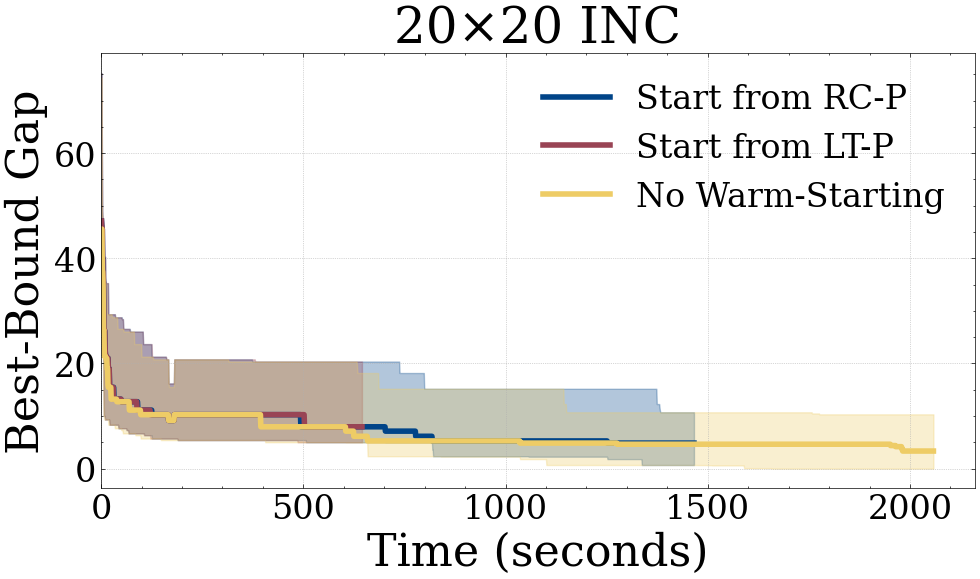

In [16]:
plotGapLogs(size=20)

[Info] Loading logs for method=RC, size=50
[Info] Loading logs for method=LT, size=50
[Info] Loading logs for method=EX, size=50
[Info] Per-instance best bounds:
  Instance 0: -2.463481
  Instance 1: -2.430473
  Instance 2: -2.45175
  Instance 3: -2.442703
  Instance 4: -2.447555
  Instance 5: -2.397192
  Instance 6: -2.502655
  Instance 7: -2.417975
  Instance 8: -2.491277
  Instance 9: -2.522878
[Success] Plot saved as ./img/gaps\gap_nc_50x50.pdf


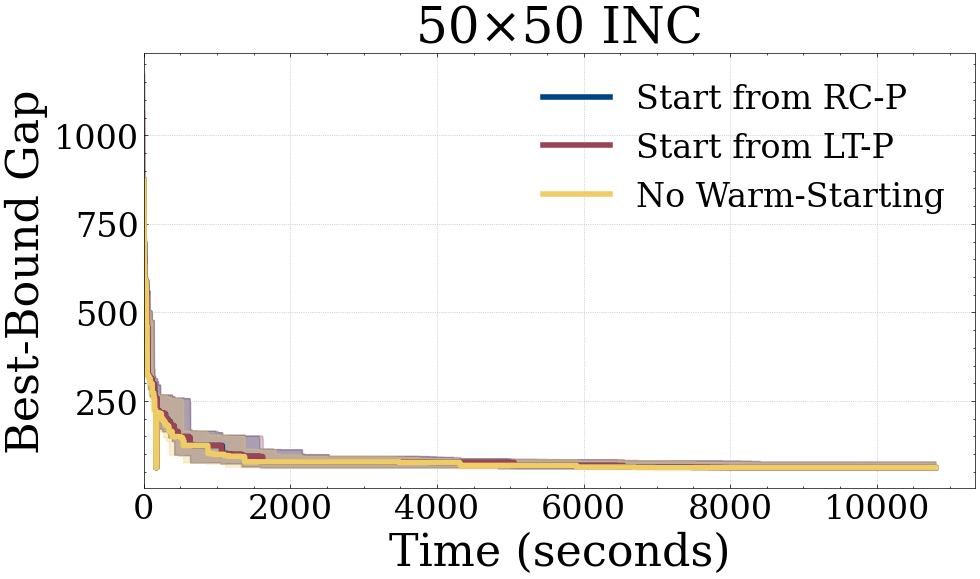

In [17]:
plotGapLogs(size=50)

[Info] Loading logs for method=RC, size=100
[Info] Loading logs for method=LT, size=100
[Info] Loading logs for method=EX, size=100
[Info] Per-instance best bounds:
  Instance 0: -5.034272
  Instance 1: -4.99904
  Instance 2: -5.006076
  Instance 3: -5.011237
  Instance 4: -5.015178
  Instance 5: -4.932345
  Instance 6: -5.006619
  Instance 7: -4.971254
  Instance 8: -5.004108
  Instance 9: -4.966141
[Success] Plot saved as ./img/gaps\gap_nc_100x100.pdf


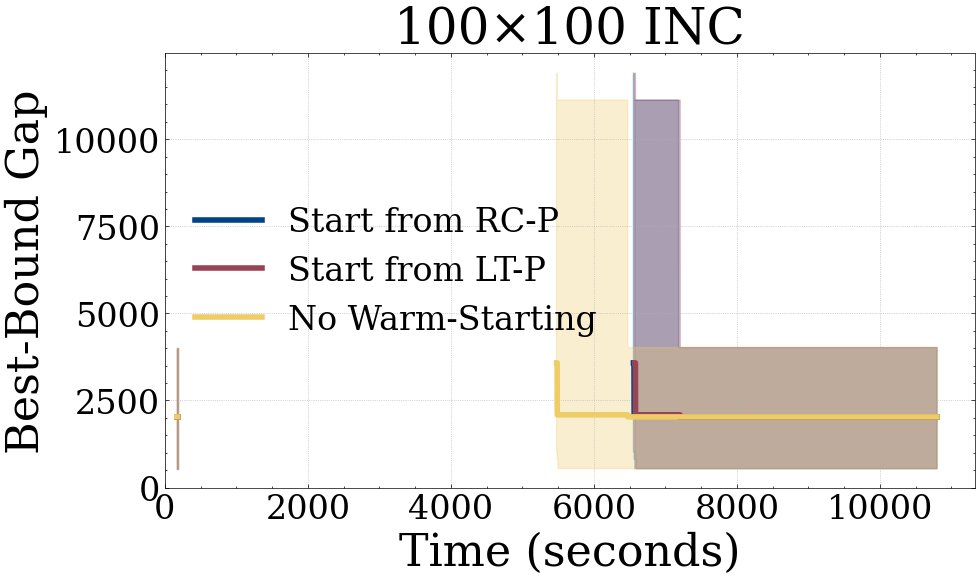

In [18]:
plotGapLogs(size=100)

[Info] Loading logs for method=RC, size=200
[Info] Loading logs for method=LT, size=200
[Info] Loading logs for method=EX, size=200
[Info] Per-instance best bounds:
  Instance 0: -10.15923
  Instance 1: -10.18697
  Instance 2: -10.22428
  Instance 3: -10.18728
  Instance 4: -10.18939
  Instance 5: -10.18523
  Instance 6: -10.23747
  Instance 7: -10.20922
  Instance 8: -10.21806
  Instance 9: -10.23693
[Success] Plot saved as ./img/gaps\gap_nc_200x200.pdf


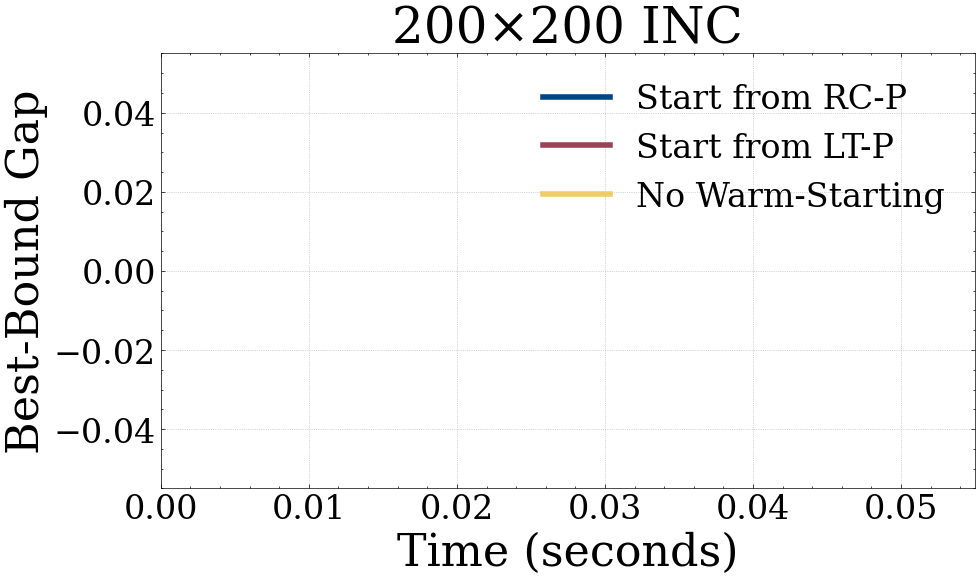

In [19]:
plotGapLogs(size=200)

[Info] Loading logs for method=RC, size=500
[Info] Loading logs for method=LT, size=500
[Info] Loading logs for method=EX, size=500
[Info] Per-instance best bounds:
  Instance 0: -24.55754
  Instance 1: -24.57188
  Instance 2: -24.55077
  Instance 3: -24.56451
  Instance 4: -24.55429
  Instance 5: -24.55859
  Instance 6: -24.55185
  Instance 7: -24.56081
  Instance 8: -24.56058
  Instance 9: -24.5805
[Success] Plot saved as ./img/gaps\gap_nc_500x500.pdf


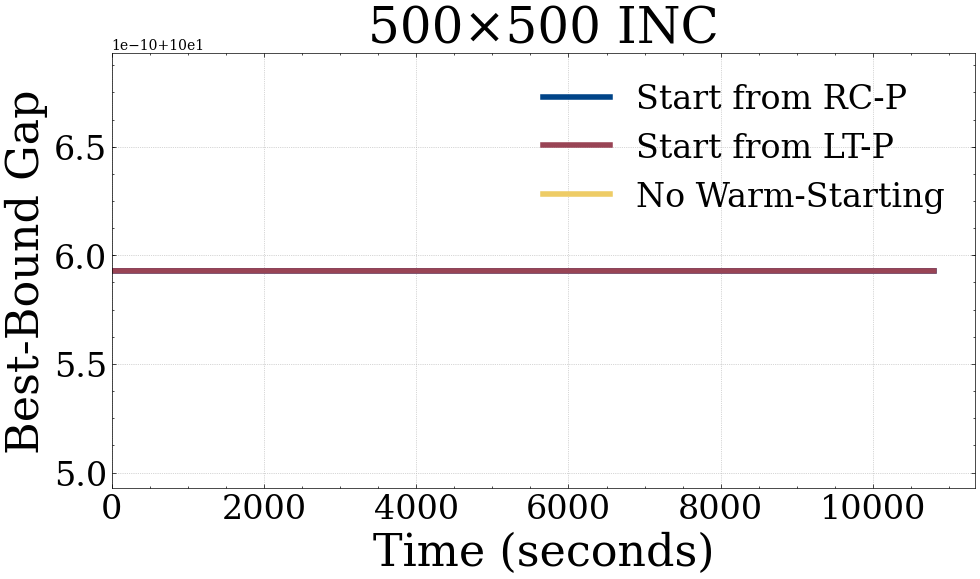

In [20]:
plotGapLogs(size=500)